<a href="https://colab.research.google.com/github/SongBeom00/Python_OpenCV/blob/develop/opencv_faster_rcnn_inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OpenCV DNN 패키지를 이용하여 Faster R-CNN 기반의 Object Detection 수행
- Tensorflow 에서 Pretrained 된 모델 파일을 OpenCV에서 로드하여 이미지와 영상에 대한 Object Detetion 수행.



입력 이미지로 사용될 이미지 다운로드/보기

In [1]:
!mkdir /content/data
!wget -O ./data/beatles01.jpg https://raw.githubusercontent.com/chulminkw/DLCV/master/data/image/beatles01.jpg

--2025-02-12 08:38:25--  https://raw.githubusercontent.com/chulminkw/DLCV/master/data/image/beatles01.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 383118 (374K) [image/jpeg]
Saving to: ‘./data/beatles01.jpg’

./data/beatles01.jp 100%[===================>] 374.14K  --.-KB/s    in 0.03s   

2025-02-12 08:38:25 (13.2 MB/s) - ‘./data/beatles01.jpg’ saved [383118/383118]



image shape :  (633, 806, 3)


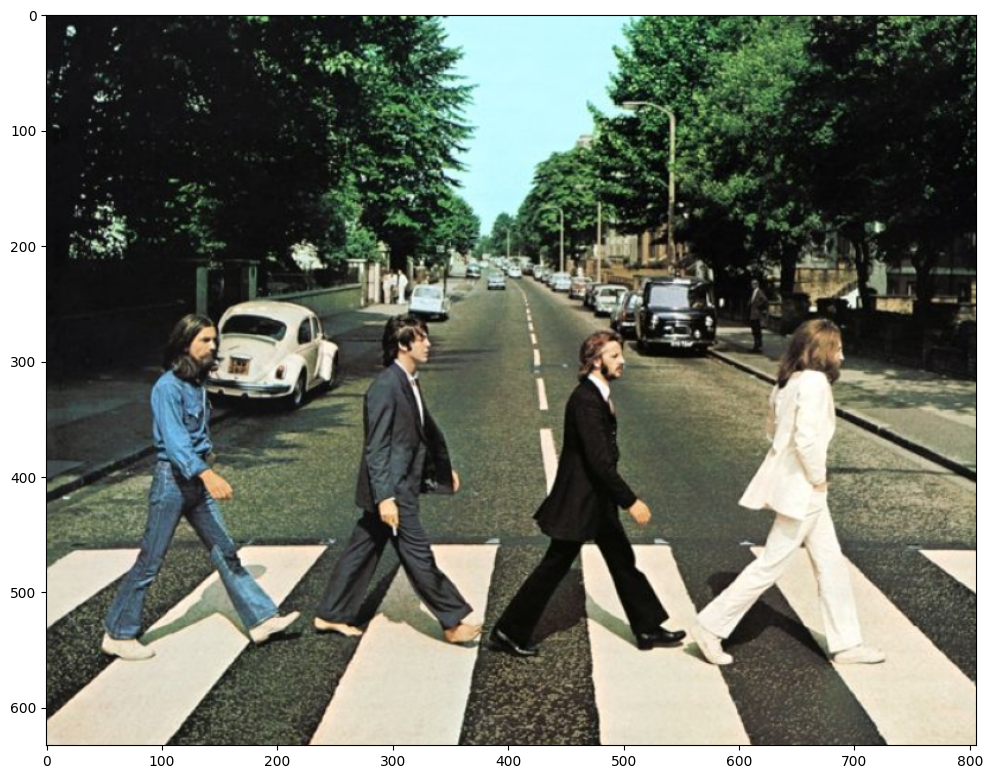

In [8]:
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

img = cv2.imread('./data/beatles01.jpg')
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

print('image shape : ',img.shape)
plt.figure(figsize=(12,12))
plt.imshow(img_rgb)

### Tensorflow에서 Pretrained 된 Inference모델(Frozen graph)와 환경파일을 다운로드 받은 후 이를 이용해 OpenCV에서 Inference 모델 생성


In [9]:
!mkdir ./pretrained
!wget -O ./pretrained/faster_rcnn_resnet50_coco_2018_01_28.tar.gz http://download.tensorflow.org/models/object_detection/faster_rcnn_resnet50_coco_2018_01_28.tar.gz
!wget -O ./pretrained/config_graph.pbtxt https://raw.githubusercontent.com/opencv/opencv_extra/master/testdata/dnn/faster_rcnn_resnet50_coco_2018_01_28.pbtxt

--2025-02-12 08:44:03--  http://download.tensorflow.org/models/object_detection/faster_rcnn_resnet50_coco_2018_01_28.tar.gz
Resolving download.tensorflow.org (download.tensorflow.org)... 142.251.188.207, 108.177.98.207, 74.125.197.207, ...
Connecting to download.tensorflow.org (download.tensorflow.org)|142.251.188.207|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 381355771 (364M) [application/x-tar]
Saving to: ‘./pretrained/faster_rcnn_resnet50_coco_2018_01_28.tar.gz’

./pretrained/faster 100%[===================>] 363.69M  26.0MB/s    in 9.1s    

2025-02-12 08:44:12 (39.9 MB/s) - ‘./pretrained/faster_rcnn_resnet50_coco_2018_01_28.tar.gz’ saved [381355771/381355771]

--2025-02-12 08:44:12--  https://raw.githubusercontent.com/opencv/opencv_extra/master/testdata/dnn/faster_rcnn_resnet50_coco_2018_01_28.pbtxt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercont

In [10]:
!tar -xvf ./pretrained/faster*.tar.gz -C ./pretrained

faster_rcnn_resnet50_coco_2018_01_28/
faster_rcnn_resnet50_coco_2018_01_28/model.ckpt.index
faster_rcnn_resnet50_coco_2018_01_28/checkpoint
faster_rcnn_resnet50_coco_2018_01_28/pipeline.config
faster_rcnn_resnet50_coco_2018_01_28/model.ckpt.data-00000-of-00001
faster_rcnn_resnet50_coco_2018_01_28/model.ckpt.meta
faster_rcnn_resnet50_coco_2018_01_28/saved_model/
faster_rcnn_resnet50_coco_2018_01_28/saved_model/saved_model.pb
faster_rcnn_resnet50_coco_2018_01_28/saved_model/variables/
faster_rcnn_resnet50_coco_2018_01_28/frozen_inference_graph.pb


In [11]:
!pwd
!ls -lia ./pretrained/faster_rcnn_resnet50_coco_2018_01_28

/content
total 296080
2365747 drwxr-xr-x 3 345018 5000      4096 Feb  1  2018 .
2365744 drwxr-xr-x 3 root   root      4096 Feb 12 08:47 ..
2365749 -rw-r--r-- 1 345018 5000        77 Feb  1  2018 checkpoint
2365756 -rw-r--r-- 1 345018 5000 120549957 Feb  1  2018 frozen_inference_graph.pb
2365751 -rw-r--r-- 1 345018 5000 176914228 Feb  1  2018 model.ckpt.data-00000-of-00001
2365748 -rw-r--r-- 1 345018 5000     14460 Feb  1  2018 model.ckpt.index
2365752 -rw-r--r-- 1 345018 5000   5675175 Feb  1  2018 model.ckpt.meta
2365750 -rw-r--r-- 1 345018 5000      3240 Feb  1  2018 pipeline.config
2365753 drwxr-xr-x 3 345018 5000      4096 Feb  1  2018 saved_model


#### dnn에서 readNetFromTensorflow()로 tensorflow inference 모델을 로딩

In [12]:
cv_net = cv2.dnn.readNetFromTensorflow('./pretrained/faster_rcnn_resnet50_coco_2018_01_28/frozen_inference_graph.pb',
                                     './pretrained/config_graph.pbtxt')

#### coco 데이터 세트의 클래스 id 별 클래스명 지정

In [13]:
# OpenCV Yolo용
labels_to_names_seq = {0:'person',1:'bicycle',2:'car',3:'motorbike',4:'aeroplane',5:'bus',6:'train',7:'truck',8:'boat',9:'traffic light',10:'fire hydrant',
                        11:'stop sign',12:'parking meter',13:'bench',14:'bird',15:'cat',16:'dog',17:'horse',18:'sheep',19:'cow',20:'elephant',
                        21:'bear',22:'zebra',23:'giraffe',24:'backpack',25:'umbrella',26:'handbag',27:'tie',28:'suitcase',29:'frisbee',30:'skis',
                        31:'snowboard',32:'sports ball',33:'kite',34:'baseball bat',35:'baseball glove',36:'skateboard',37:'surfboard',38:'tennis racket',39:'bottle',40:'wine glass',
                        41:'cup',42:'fork',43:'knife',44:'spoon',45:'bowl',46:'banana',47:'apple',48:'sandwich',49:'orange',50:'broccoli',
                        51:'carrot',52:'hot dog',53:'pizza',54:'donut',55:'cake',56:'chair',57:'sofa',58:'pottedplant',59:'bed',60:'diningtable',
                        61:'toilet',62:'tvmonitor',63:'laptop',64:'mouse',65:'remote',66:'keyboard',67:'cell phone',68:'microwave',69:'oven',70:'toaster',
                        71:'sink',72:'refrigerator',73:'book',74:'clock',75:'vase',76:'scissors',77:'teddy bear',78:'hair drier',79:'toothbrush' }

In [14]:
# OpenCV Tensorflow Faster-RCNN용
labels_to_names_0 = {0:'person',1:'bicycle',2:'car',3:'motorcycle',4:'airplane',5:'bus',6:'train',7:'truck',8:'boat',9:'traffic light',
                    10:'fire hydrant',11:'street sign',12:'stop sign',13:'parking meter',14:'bench',15:'bird',16:'cat',17:'dog',18:'horse',19:'sheep',
                    20:'cow',21:'elephant',22:'bear',23:'zebra',24:'giraffe',25:'hat',26:'backpack',27:'umbrella',28:'shoe',29:'eye glasses',
                    30:'handbag',31:'tie',32:'suitcase',33:'frisbee',34:'skis',35:'snowboard',36:'sports ball',37:'kite',38:'baseball bat',39:'baseball glove',
                    40:'skateboard',41:'surfboard',42:'tennis racket',43:'bottle',44:'plate',45:'wine glass',46:'cup',47:'fork',48:'knife',49:'spoon',
                    50:'bowl',51:'banana',52:'apple',53:'sandwich',54:'orange',55:'broccoli',56:'carrot',57:'hot dog',58:'pizza',59:'donut',
                    60:'cake',61:'chair',62:'couch',63:'potted plant',64:'bed',65:'mirror',66:'dining table',67:'window',68:'desk',69:'toilet',
                    70:'door',71:'tv',72:'laptop',73:'mouse',74:'remote',75:'keyboard',76:'cell phone',77:'microwave',78:'oven',79:'toaster',
                    80:'sink',81:'refrigerator',82:'blender',83:'book',84:'clock',85:'vase',86:'scissors',87:'teddy bear',88:'hair drier',89:'toothbrush',
                    90:'hair brush'}

In [15]:
labels_to_names = {1:'person',2:'bicycle',3:'car',4:'motorcycle',5:'airplane',6:'bus',7:'train',8:'truck',9:'boat',10:'traffic light',
                    11:'fire hydrant',12:'street sign',13:'stop sign',14:'parking meter',15:'bench',16:'bird',17:'cat',18:'dog',19:'horse',20:'sheep',
                    21:'cow',22:'elephant',23:'bear',24:'zebra',25:'giraffe',26:'hat',27:'backpack',28:'umbrella',29:'shoe',30:'eye glasses',
                    31:'handbag',32:'tie',33:'suitcase',34:'frisbee',35:'skis',36:'snowboard',37:'sports ball',38:'kite',39:'baseball bat',40:'baseball glove',
                    41:'skateboard',42:'surfboard',43:'tennis racket',44:'bottle',45:'plate',46:'wine glass',47:'cup',48:'fork',49:'knife',50:'spoon',
                    51:'bowl',52:'banana',53:'apple',54:'sandwich',55:'orange',56:'broccoli',57:'carrot',58:'hot dog',59:'pizza',60:'donut',
                    61:'cake',62:'chair',63:'couch',64:'potted plant',65:'bed',66:'mirror',67:'dining table',68:'window',69:'desk',70:'toilet',
                    71:'door',72:'tv',73:'laptop',74:'mouse',75:'remote',76:'keyboard',77:'cell phone',78:'microwave',79:'oven',80:'toaster',
                    81:'sink',82:'refrigerator',83:'blender',84:'book',85:'clock',86:'vase',87:'scissors',88:'teddy bear',89:'hair drier',90:'toothbrush',
                    91:'hair brush'}

### 이미지를 preprocessing 수행하여 Network 에 입력하고 Object Detection 수행 후 결과를 이미지에 시각화

In [16]:
img.shape

(633, 806, 3)

(1, 1, 100, 7)
person: 0.9998
person: 0.9996
person: 0.9993
person: 0.9970
person: 0.8995
car: 0.8922
car: 0.7602
car: 0.7415
car: 0.6929
car: 0.6918
car: 0.6896
car: 0.6717
car: 0.6521
car: 0.5730
car: 0.5679
car: 0.5261
car: 0.5012


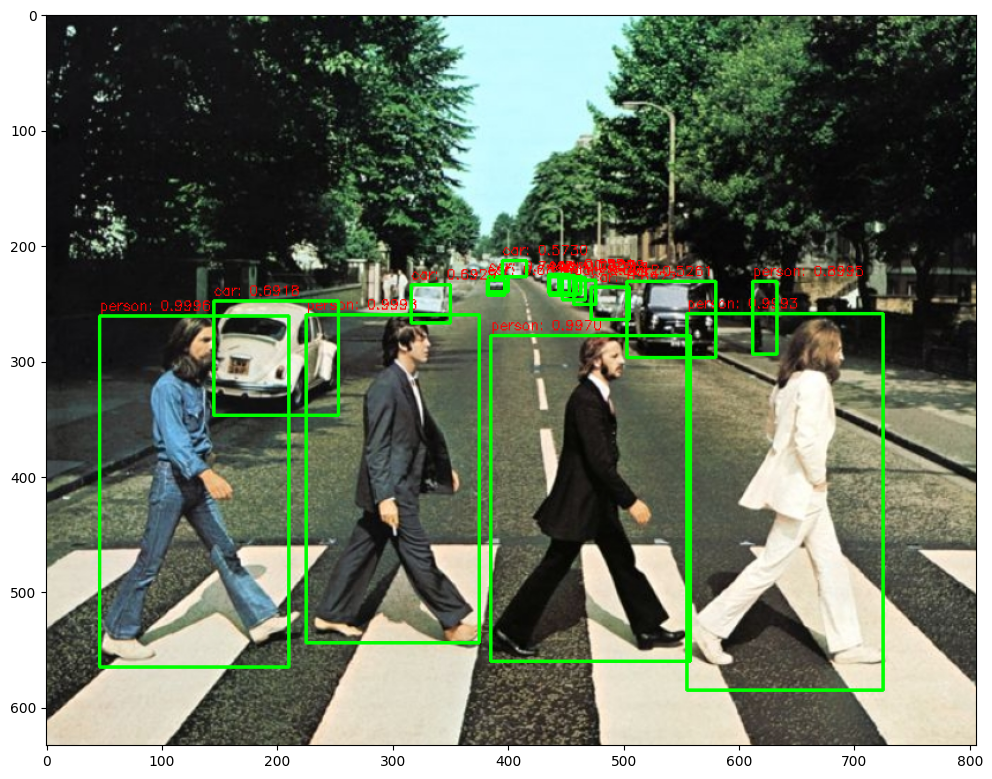

In [22]:

rows =img.shape[0]
cols = img.shape[1]

draw_img = img.copy()

# 원본 이미지 배열 BGR을 RGB로 변환하여 배열 입력, Tensorflow Faster RCNN은 마지막 classification layer 가 Dense가 아니여서 size를 고정
cv_net.setInput(cv2.dnn.blobFromImage(img,swapRB=True, crop=False))

# Object Detection 수행하여 결과를 cvOut으로 반환
cv_out = cv_net.forward()
print(cv_out.shape)
# (1, 1, 100, 7) -> 값이 없다 1,1 / object detect한 개수 100  -> filtering out을 해야합니다. / 4차원 배열 7개 값

# bounding box의 테두리와 caption 글자색 지정
green_color=(0, 255, 0)
red_color=(0, 0, 255)

# detected 된 object들을 iteration 하면서 정보 추출
for detection in cv_out[0,0,:,:]: # 100번 loop
    score = float(detection[2]) #
    class_id = int(detection[1]) # 0 : person (사람)
    # detected된 object들의 score가 0.5 이상만 추출
    if score > 0.5:
        # detected된 object들은 scale된 기준으로 예측되었으므로 다시 원본 이미지 비율로 계산
        left = detection[3] * cols
        top = detection[4] * rows
        right = detection[5] * cols
        bottom = detection[6] * rows
        # labels_to_names_seq 딕셔너리로 class_id값을 클래스명으로 변경.|
        caption = "{}: {:.4f}".format(labels_to_names_0[class_id], score)
        print(caption)
        #cv2.rectangle()은 인자로 들어온 draw_img에 사각형을 그림. 위치 인자는 반드시 정수형.
        cv2.rectangle(draw_img, (int(left), int(top)), (int(right), int(bottom)), color=green_color, thickness=2)
        cv2.putText(draw_img, caption, (int(left), int(top - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.4, red_color, 1)

img_rgb = cv2.cvtColor(draw_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 12))
plt.imshow(img_rgb)

In [23]:
cv_out

array([[[[0.00000000e+00, 0.00000000e+00, 9.99780953e-01,
          2.80248195e-01, 4.11070466e-01, 4.66062039e-01,
          8.59829783e-01],
         [0.00000000e+00, 0.00000000e+00, 9.99587953e-01,
          5.82913086e-02, 4.13466066e-01, 2.61212587e-01,
          8.93701553e-01],
         [0.00000000e+00, 0.00000000e+00, 9.99258697e-01,
          6.89431906e-01, 4.10281926e-01, 8.99752855e-01,
          9.24375534e-01],
         [0.00000000e+00, 0.00000000e+00, 9.96988714e-01,
          4.78255481e-01, 4.39303011e-01, 6.92748427e-01,
          8.84738088e-01],
         [0.00000000e+00, 0.00000000e+00, 8.99451137e-01,
          7.59500206e-01, 3.65392357e-01, 7.86593020e-01,
          4.65826124e-01],
         [0.00000000e+00, 2.00000000e+00, 8.92164230e-01,
          5.86493194e-01, 3.73032689e-01, 6.27667129e-01,
          4.18615639e-01],
         [0.00000000e+00, 2.00000000e+00, 7.60227084e-01,
          5.41625261e-01, 3.59284222e-01, 5.69990754e-01,
          3.85314763e-01],

### 단일 이미지의 object detection을 함수로 생성

In [24]:
import time

def get_detected_img(cv_net, img_array, score_threshold, use_copied_array=True, is_print=True):

    rows = img_array.shape[0]
    cols = img_array.shape[1]

    draw_img = None
    if use_copied_array:
        draw_img = img_array.copy()
    else:
        draw_img = img_array

    cv_net.setInput(cv2.dnn.blobFromImage(img_array, swapRB=True, crop=False))

    start = time.time()
    cv_out = cv_net.forward()

    green_color=(0, 255, 0)
    red_color=(0, 0, 255)

    # detected 된 object들을 iteration 하면서 정보 추출
    for detection in cv_out[0,0,:,:]:
        score = float(detection[2])
        class_id = int(detection[1])
        # detected된 object들의 score가 함수 인자로 들어온 score_threshold 이상만 추출
        if score > score_threshold:
            # detected된 object들은 scale된 기준으로 예측되었으므로 다시 원본 이미지 비율로 계산
            left = detection[3] * cols
            top = detection[4] * rows
            right = detection[5] * cols
            bottom = detection[6] * rows
            # labels_to_names 딕셔너리로 class_id값을 클래스명으로 변경. opencv에서는 class_id + 1로 매핑해야함.
            caption = "{}: {:.4f}".format(labels_to_names_0[class_id], score)
            print(caption)
            #cv2.rectangle()은 인자로 들어온 draw_img에 사각형을 그림. 위치 인자는 반드시 정수형.
            cv2.rectangle(draw_img, (int(left), int(top)), (int(right), int(bottom)), color=green_color, thickness=2)
            cv2.putText(draw_img, caption, (int(left), int(top - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.4, red_color, 1)
    if is_print:
        print('Detection 수행시간:',round(time.time() - start, 2),"초")

    return draw_img

image shape (633, 806, 3)
person: 0.9998
person: 0.9996
person: 0.9993
person: 0.9970
person: 0.8995
car: 0.8922
car: 0.7602
car: 0.7415
car: 0.6929
car: 0.6918
car: 0.6896
car: 0.6717
car: 0.6521
car: 0.5730
car: 0.5679
car: 0.5261
car: 0.5012
Detection 수행시간: 6.57 초


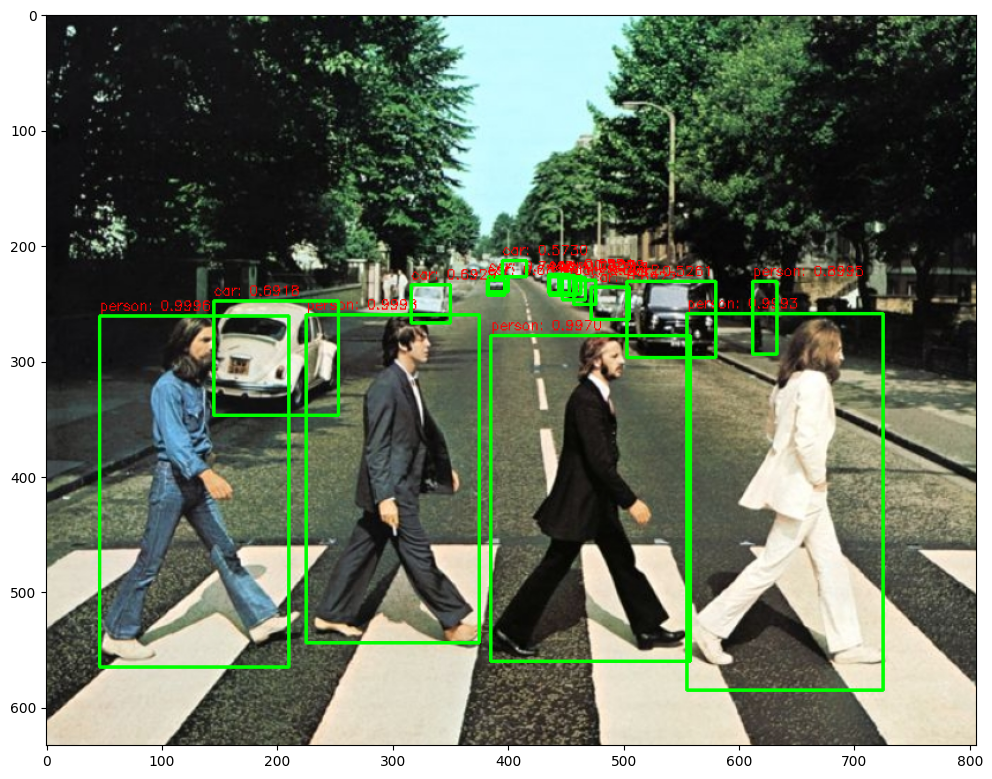

In [27]:
img = cv2.imread('./data/beatles01.jpg')
print('image shape',img.shape)

# tensorflow inference 모델 로딩
cv_net = cv2.dnn.readNetFromTensorflow('./pretrained/faster_rcnn_resnet50_coco_2018_01_28/frozen_inference_graph.pb',
                                     './pretrained/config_graph.pbtxt')

# Object Detetion 수행 후 시각화
draw_img =get_detected_img(cv_net,img,score_threshold=0.5,use_copied_array=True,is_print=True)

img_rgb = cv2.cvtColor(draw_img,cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,12))
plt.imshow(img_rgb)





In [28]:
!wget -O ./data/baseball01.jpg https://raw.githubusercontent.com/chulminkw/DLCV/master/data/image/baseball01.jpg

--2025-02-12 09:20:05--  https://raw.githubusercontent.com/chulminkw/DLCV/master/data/image/baseball01.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 76279 (74K) [image/jpeg]
Saving to: ‘./data/baseball01.jpg’

./data/baseball01.j 100%[===================>]  74.49K  --.-KB/s    in 0.02s   

2025-02-12 09:20:05 (4.36 MB/s) - ‘./data/baseball01.jpg’ saved [76279/76279]



image shape: (476, 735, 3)
person: 0.9998
person: 0.9997
person: 0.9977
baseball glove: 0.9815
sports ball: 0.8867
baseball bat: 0.8420
Detection 수행시간: 7.49 초


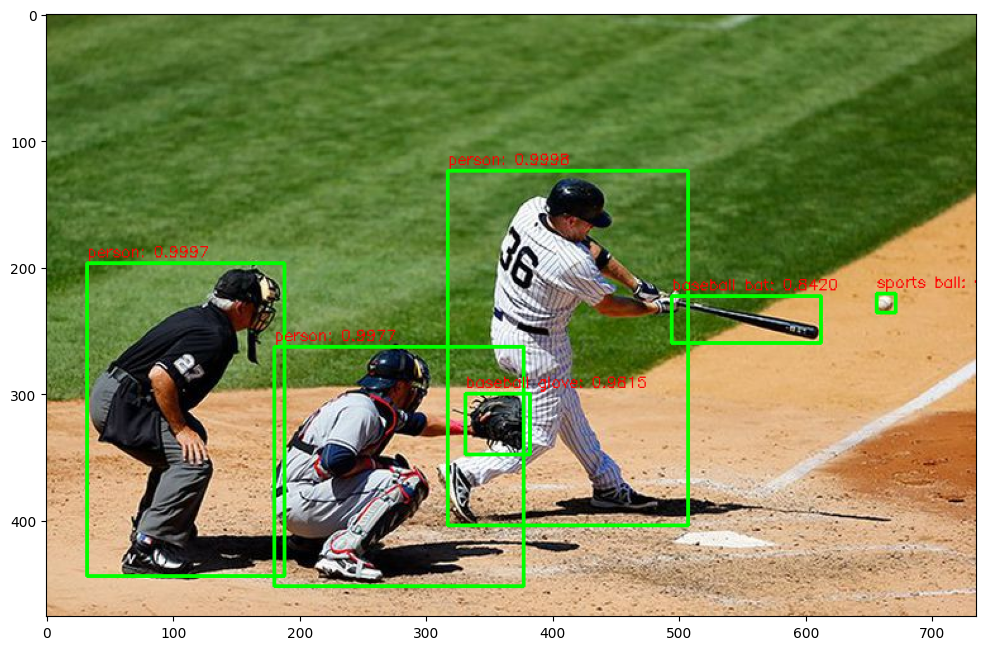

In [29]:
img = cv2.imread('./data/baseball01.jpg')
print('image shape:', img.shape)

# tensorflow inference 모델 로딩
cv_net = cv2.dnn.readNetFromTensorflow('./pretrained/faster_rcnn_resnet50_coco_2018_01_28/frozen_inference_graph.pb',
                                     './pretrained/config_graph.pbtxt')
# Object Detetion 수행 후 시각화
draw_img = get_detected_img(cv_net, img, score_threshold=0.5, use_copied_array=True, is_print=True)

img_rgb = cv2.cvtColor(draw_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 12))
plt.imshow(img_rgb)

image shape: (430, 430, 3)
apple: 0.9555
Detection 수행시간: 6.69 초


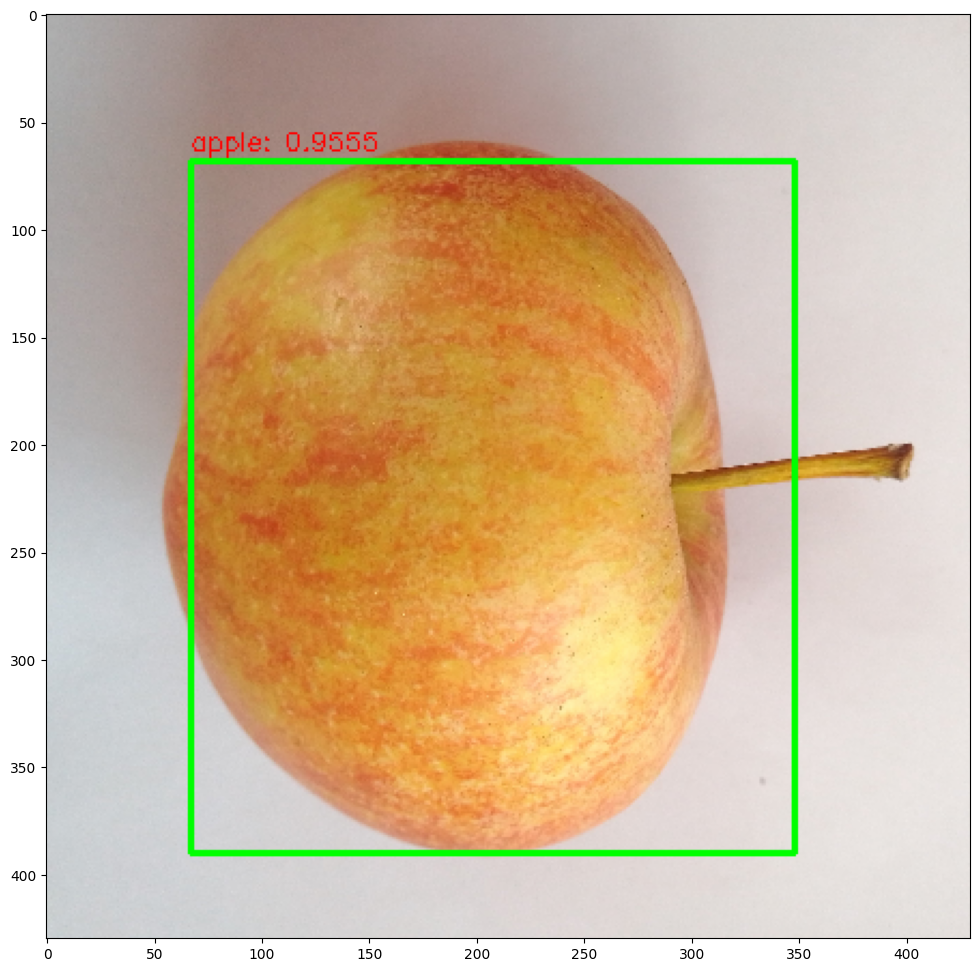

In [35]:
img = cv2.imread('/content/apple.jpg')
img = cv2.resize(img,(430,430))
print('image shape:', img.shape)


# tensorflow inference 모델 로딩
cv_net = cv2.dnn.readNetFromTensorflow('./pretrained/faster_rcnn_resnet50_coco_2018_01_28/frozen_inference_graph.pb',
                                     './pretrained/config_graph.pbtxt')
# Object Detetion 수행 후 시각화
draw_img = get_detected_img(cv_net, img, score_threshold=0.5, use_copied_array=True, is_print=True)

img_rgb = cv2.cvtColor(draw_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 12))
plt.imshow(img_rgb)

image shape: (430, 430, 3)
orange: 0.7603
donut: 0.5111
Detection 수행시간: 6.46 초


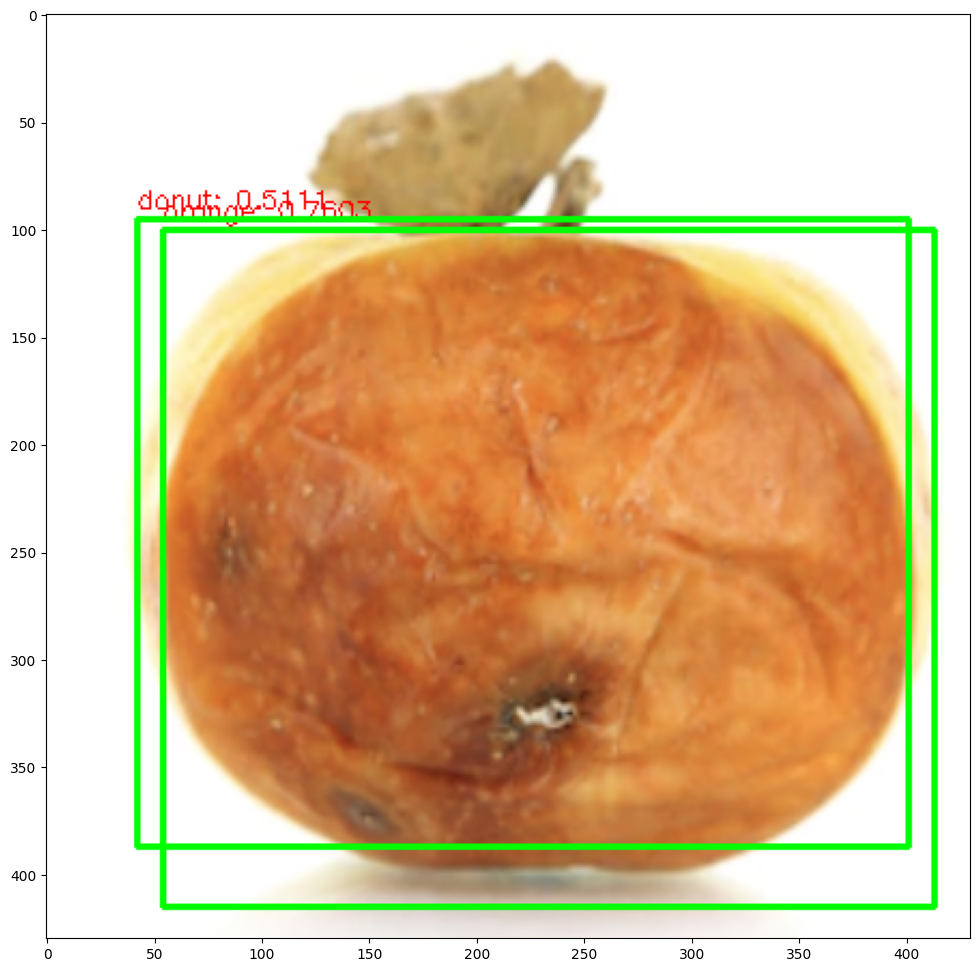

In [37]:
img = cv2.imread('/content/bad_apple.png')
img = cv2.resize(img,(430,430))
print('image shape:', img.shape)


# tensorflow inference 모델 로딩
cv_net = cv2.dnn.readNetFromTensorflow('./pretrained/faster_rcnn_resnet50_coco_2018_01_28/frozen_inference_graph.pb',
                                     './pretrained/config_graph.pbtxt')
# Object Detetion 수행 후 시각화
draw_img = get_detected_img(cv_net, img, score_threshold=0.5, use_copied_array=True, is_print=True)

img_rgb = cv2.cvtColor(draw_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 12))
plt.imshow(img_rgb)

### Video Object Detection 수행

In [38]:
!wget -O ./data/Jonh_Wick_small.mp4 https://github.com/chulminkw/DLCV/blob/master/data/video/John_Wick_small.mp4?raw=true

--2025-02-12 09:26:17--  https://github.com/chulminkw/DLCV/blob/master/data/video/John_Wick_small.mp4?raw=true
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/chulminkw/DLCV/raw/refs/heads/master/data/video/John_Wick_small.mp4 [following]
--2025-02-12 09:26:17--  https://github.com/chulminkw/DLCV/raw/refs/heads/master/data/video/John_Wick_small.mp4
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/chulminkw/DLCV/refs/heads/master/data/video/John_Wick_small.mp4 [following]
--2025-02-12 09:26:18--  https://raw.githubusercontent.com/chulminkw/DLCV/refs/heads/master/data/video/John_Wick_small.mp4
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.

In [39]:
video_input_path = '/content/data/Jonh_Wick_small.mp4'

cap = cv2.VideoCapture(video_input_path)
frame_cnt = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print('총 Frame 갯수:', frame_cnt)

총 Frame 갯수: 58


In [40]:
video_input_path = '/content/data/Jonh_Wick_small.mp4'
video_output_path = './data/John_Wick_small_cv01.mp4'

cap = cv2.VideoCapture(video_input_path)

codec = cv2.VideoWriter_fourcc(*'XVID')

vid_size = (round(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),round(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))
vid_fps = cap.get(cv2.CAP_PROP_FPS )

vid_writer = cv2.VideoWriter(video_output_path, codec, vid_fps, vid_size)

frame_cnt = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print('총 Frame 갯수:', frame_cnt)

총 Frame 갯수: 58


In [41]:
# bounding box의 테두리와 caption 글자색 지정
green_color=(0, 255, 0)
red_color=(0, 0, 255)

while True:

    hasFrame, img_frame = cap.read()
    if not hasFrame: # 뒤에 이미지가 읽을 게 없으면
        print('더 이상 처리할 frame이 없습니다.')
        break

    rows = img_frame.shape[0]
    cols = img_frame.shape[1]
    # 원본 이미지 배열 BGR을 RGB로 변환하여 배열 입력
    cv_net.setInput(cv2.dnn.blobFromImage(img_frame,  swapRB=True, crop=False))

    start= time.time()
    # Object Detection 수행하여 결과를 cv_out으로 반환
    cv_out = cv_net.forward()
    frame_index = 0
    # detected 된 object들을 iteration 하면서 정보 추출
    for detection in cv_out[0,0,:,:]: # 58번 loop 를 돌립니다.
        score = float(detection[2])
        class_id = int(detection[1])
        # detected된 object들의 score가 0.5 이상만 추출
        if score > 0.5:
            # detected된 object들은 scale된 기준으로 예측되었으므로 다시 원본 이미지 비율로 계산
            left = detection[3] * cols
            top = detection[4] * rows
            right = detection[5] * cols
            bottom = detection[6] * rows
            # labels_to_names_0딕셔너리로 class_id값을 클래스명으로 변경.
            caption = "{}: {:.4f}".format(labels_to_names_0[class_id], score)
            #print(class_id, caption)
            #cv2.rectangle()은 인자로 들어온 draw_img에 사각형을 그림. 위치 인자는 반드시 정수형.
            cv2.rectangle(img_frame, (int(left), int(top)), (int(right), int(bottom)), color=green_color, thickness=2)
            cv2.putText(img_frame, caption, (int(left), int(top - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, red_color, 1)
    print('Detection 수행 시간:', round(time.time()-start, 2),'초')
    vid_writer.write(img_frame)
# end of while loop

vid_writer.release()
cap.release()

Detection 수행 시간: 5.77 초
Detection 수행 시간: 7.16 초
Detection 수행 시간: 6.06 초
Detection 수행 시간: 7.34 초
Detection 수행 시간: 15.65 초
Detection 수행 시간: 6.01 초
Detection 수행 시간: 6.41 초
Detection 수행 시간: 6.46 초
Detection 수행 시간: 6.23 초
Detection 수행 시간: 7.41 초
Detection 수행 시간: 6.77 초
Detection 수행 시간: 6.51 초
Detection 수행 시간: 6.58 초
Detection 수행 시간: 6.6 초
Detection 수행 시간: 5.85 초
Detection 수행 시간: 6.6 초
Detection 수행 시간: 5.72 초
Detection 수행 시간: 6.91 초
Detection 수행 시간: 5.64 초
Detection 수행 시간: 6.98 초
Detection 수행 시간: 5.6 초
Detection 수행 시간: 6.99 초
Detection 수행 시간: 5.61 초
Detection 수행 시간: 6.57 초
Detection 수행 시간: 5.89 초
Detection 수행 시간: 6.56 초
Detection 수행 시간: 6.39 초
Detection 수행 시간: 6.32 초
Detection 수행 시간: 6.23 초
Detection 수행 시간: 5.64 초
Detection 수행 시간: 6.76 초
Detection 수행 시간: 5.59 초
Detection 수행 시간: 6.87 초
Detection 수행 시간: 5.7 초
Detection 수행 시간: 6.91 초
Detection 수행 시간: 5.37 초
Detection 수행 시간: 6.91 초
Detection 수행 시간: 5.72 초
Detection 수행 시간: 6.72 초
Detection 수행 시간: 6.15 초
Detection 수행 시간: 6.45 초
Detection 수행 시간: 6.

In [42]:
def do_detected_video(cv_net, input_path, output_path, score_threshold, is_print):

    cap = cv2.VideoCapture(input_path)

    codec = cv2.VideoWriter_fourcc(*'XVID')

    vid_size = (round(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),round(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))
    vid_fps = cap.get(cv2.CAP_PROP_FPS)

    vid_writer = cv2.VideoWriter(output_path, codec, vid_fps, vid_size)

    frame_cnt = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print('총 Frame 갯수:', frame_cnt)

    green_color=(0, 255, 0)
    red_color=(0, 0, 255)
    while True:
        hasFrame, img_frame = cap.read()
        if not hasFrame:
            print('더 이상 처리할 frame이 없습니다.')
            break

        img_frame = get_detected_img(cv_net, img_frame, score_threshold=score_threshold, use_copied_array=False, is_print=is_print)

        vid_writer.write(img_frame)
    # end of while loop

    vid_writer.release()
    cap.release()

In [43]:
do_detected_video(cv_net, '/content/data/Jonh_Wick_small.mp4', './data/John_Wick_small_02.mp4', 0.2, False)

총 Frame 갯수: 58
car: 0.9882
car: 0.9622
person: 0.9495
car: 0.9266
car: 0.8772
motorcycle: 0.6607
car: 0.3988
car: 0.3763
bicycle: 0.3498
person: 0.2871
car: 0.2583
car: 0.2150
book: 0.2069
car: 0.9881
car: 0.9643
person: 0.9581
car: 0.9318
car: 0.8992
motorcycle: 0.5682
person: 0.4459
car: 0.4418
bicycle: 0.4216
car: 0.4189
person: 0.2940
car: 0.2545
car: 0.2318
car: 0.9903
car: 0.9833
motorcycle: 0.9532
car: 0.9115
car: 0.8625
person: 0.7814
person: 0.5169
car: 0.4893
car: 0.4251
person: 0.3087
airplane: 0.2046
car: 0.9919
car: 0.9909
car: 0.9870
motorcycle: 0.8655
person: 0.7585
person: 0.7484
person: 0.7375
car: 0.7361
person: 0.7200
car: 0.6120
umbrella: 0.4362
person: 0.3580
person: 0.2285
person: 0.2171
car: 0.9933
car: 0.9817
motorcycle: 0.9781
car: 0.9530
car: 0.7823
person: 0.5313
person: 0.4869
truck: 0.4717
person: 0.4709
car: 0.2064
car: 0.9799
car: 0.9678
car: 0.9496
person: 0.8299
car: 0.6521
motorcycle: 0.6003
person: 0.4792
car: 0.4465
car: 0.4120
person: 0.2719
truck: 